<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
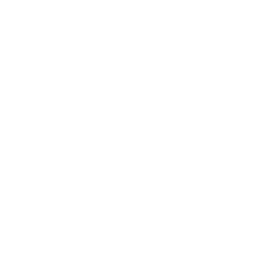
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">分割区法によるプロセス最適化</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 製造 / 品質工学 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

本ノートブックは、射出成形プロセスに対する分割区法実験計画を解析する。主区(whole-plot)
要因は**機械**(4水準: MACH_A~MACH_D)であり、これは変更が難しい要因である。副区
(sub-plot)要因は**速度設定**(5水準: 60, 80, 100, 120, 140 RPM)であり、こちらは
変更が容易である。各機械 x 速度の組み合わせについて5回の反復測定を行い、合計100件の
欠陥率観測値を得る。

`PROC MIXED`は、**機械をランダム効果**(主区の誤差層)として、**速度を固定効果**
(副区要因)として扱うことで、制限randomization構造を正しく当てはめる。この解析では
2つの分散成分を推定し、速度効果を検定し、欠陥率を最小化する稼働速度を特定するための
Tukey調整済み速度最小二乗平均のペアワイズ比較を行う。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | 分割区法実験データ: 4機械 x 5速度 x 5反復 | 100 |

---

In [1]:
/* --------------------------------------------------------
   合成の分割区法射出成形データを生成する
   4機械(主区) x 5速度(副区) x 5反復
   各主区に追加反復を持たせる
   -------------------------------------------------------- */
データ work.molding_experiment;
    呼出 streaminit(42);
    配列 machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    配列 speed_settings[5] _temporary_ (60 80 100 120 140);
    /* 真の機械効果(ランダム) */
    配列 mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* 真の速度効果(固定、最適点は約100付近の二次関数) */
    配列 speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    繰返 whole_plot = 1 から 5;
        繰返 m = 1 から 4;
            machine = machine_names[m];
            machine_id = cat('WP_', PUT(whole_plot, z2.), '_', machine);
            /* 主区反復効果 */
            wp_noise = rand('normal', 0, 1.5);
            繰返 s = 1 から 5;
                speed = speed_settings[s];
                speed_label = cat(PUT(speed, 3.), 'RPM');
                /* 各主区内の副区反復 */
                繰返 rep = 1 から 5;
                    obs_id + 1;
                    /* 欠陥率: 切片 + 機械 + 速度 + 交互作用 + ノイズ */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    もし defect_rate < 0 なら defect_rate = 0.01;
                    /* 副次的応答変数: 引張強度 */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    出力;
                終了;
            終了;
        終了;
    終了;
    削除 m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
実行;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   ベースライン: 機械 x 速度別の欠陥率サマリー
   -------------------------------------------------------- */
処理 MEANS データ=work.molding_experiment n mean std;
    分類 machine speed_label;
    変数 defect_rate tensile_strength;
    見出 machine='機械' speed_label='速度設定' defect_rate='欠陥率(%)' tensile_strength='引張強度';
    表題 '機械・速度別 欠陥率と引張強度';
実行;

                                                    機械・速度別 欠陥率と引張強度                                                     

                                                  The MEANS Procedure

                                      Analysis Variable : defect_rate 欠陥率(%)

        機械        速度設定                  N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        MACH_A     60RPM                    5     12.9460000      1.0100149
        MACH_A     80RPM                    5     10.0160000      0.6740401
        MACH_A    100RPM                    5      7.5980000      0.9787083
        MACH_A    120RPM                    5     10.2660000      0.9490416
        MACH_A    140RPM                    5     13.7120000      0.9359594
        MACH_B     60RPM                    5     11.7420000      0.9476656
        MACH_B     80RPM                    5      8.5580000      1.0129018
        MACH_B    100RPM                    5


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                    機械・速度別 欠陥率と引張強度                                                     




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


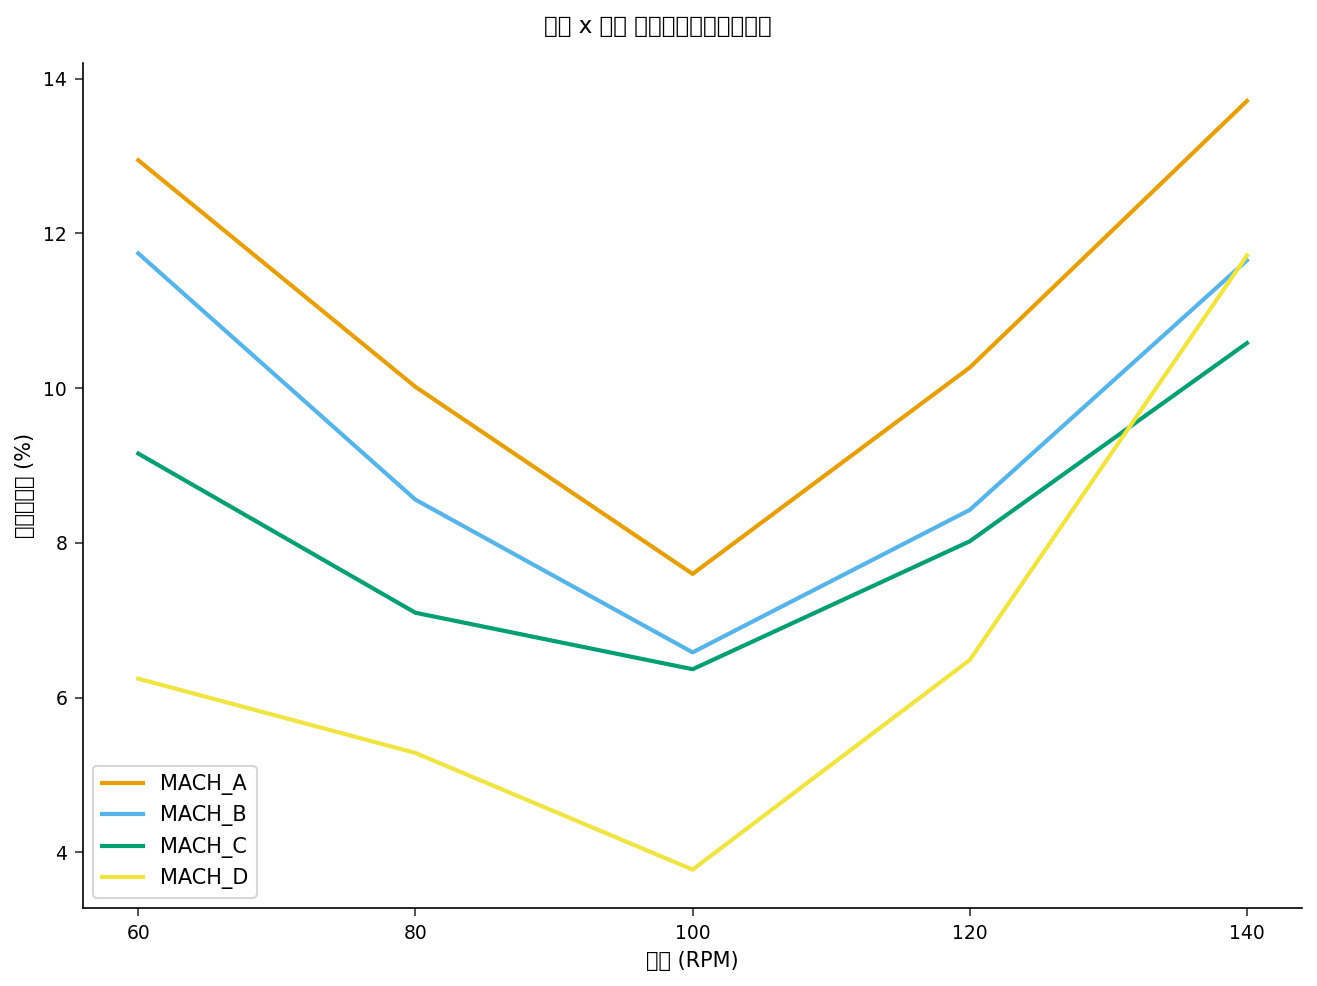

In [3]:
/* --------------------------------------------------------
   交互作用プロット: 速度 x 機械別の平均欠陥率
   -------------------------------------------------------- */
処理 MEANS データ=work.molding_experiment NOPRINT;
    分類 machine speed;
    変数 defect_rate;
    出力 out=work.cell_means mean=mean_defect;
実行;

処理 SGPLOT データ=work.cell_means(where=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS 見出='速度 (RPM)' VALUES=(60 80 100 120 140);
    YAXIS 見出='平均欠陥率 (%)';
    表題 '機械 x 速度 交互作用プロファイル';
実行;

---

                                                    機械・速度別 欠陥率と引張強度                                                     

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable                欠陥率(%)
Estimation Method                   REML
Degrees of Freedom Method  Kenward-Roger
Number of Observations               100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

          Type III Tests of Fixed Effects           

Effect          Num DF    Den DF   F Value    Pr > F
------------  --------  --------  --------  --------
速度設定                 4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC (Smaller is Better)  361.3513
BIC (Small


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


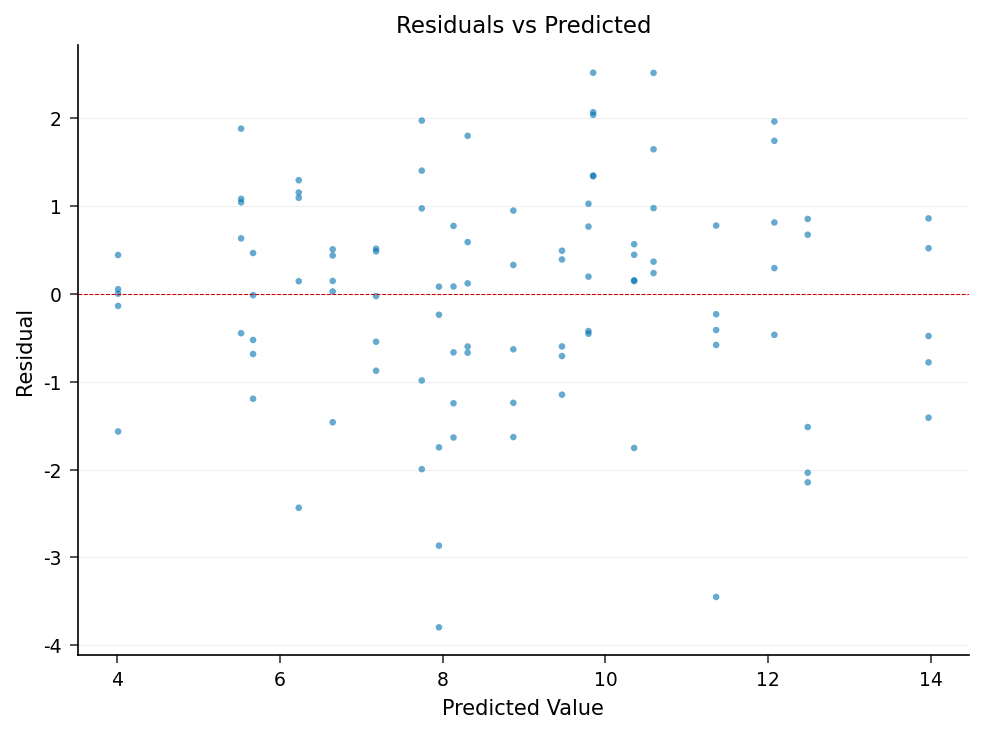

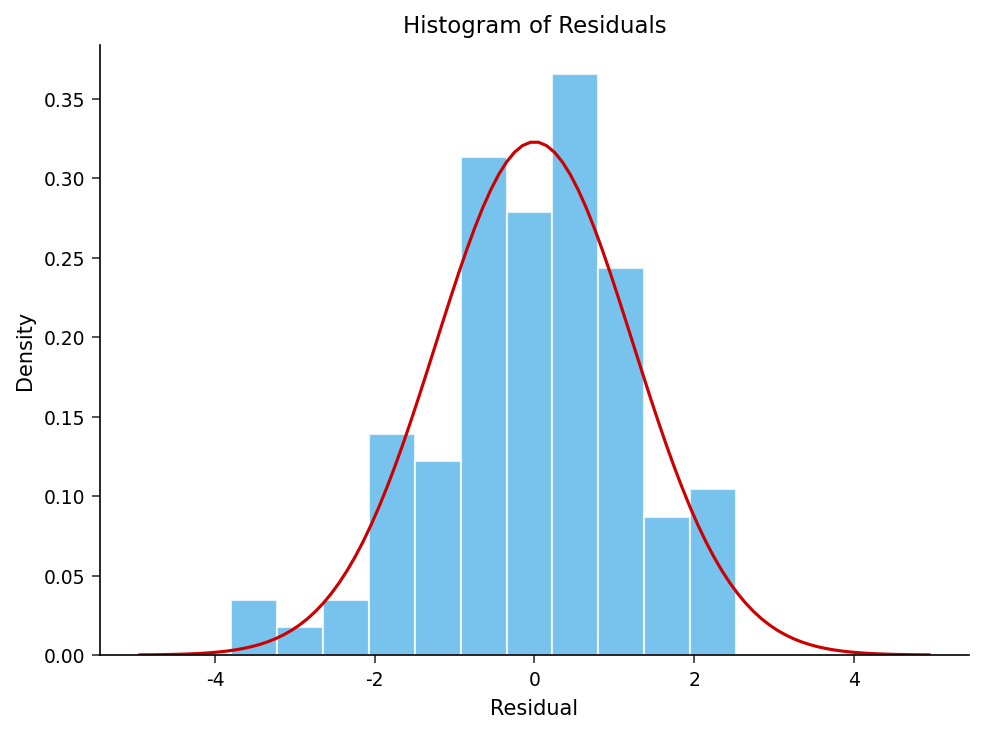

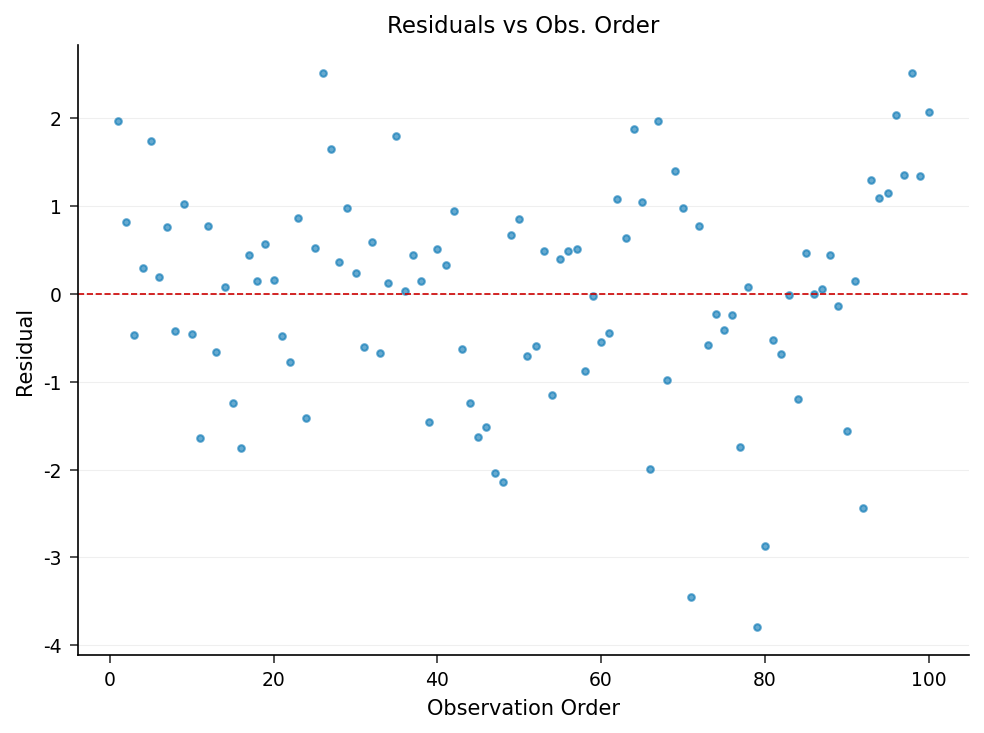

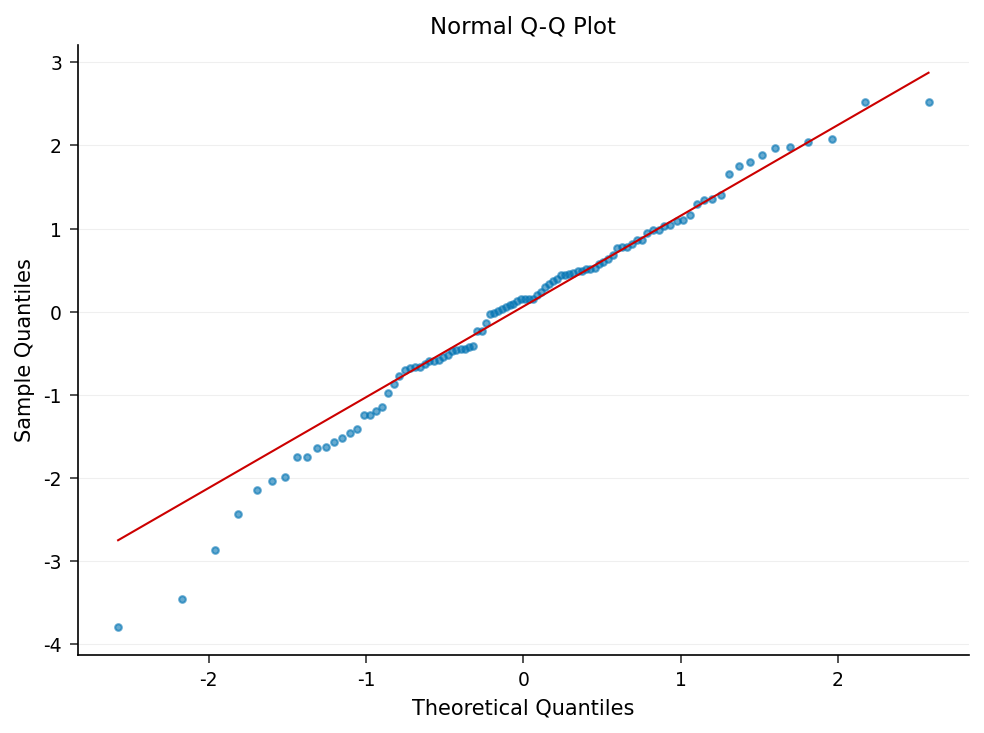

In [4]:
/* --------------------------------------------------------
   分割区法混合モデル解析
   機械はランダム(主区誤差)
   速度は固定(副区要因)
   -------------------------------------------------------- */
処理 MIXED データ=work.molding_experiment METHOD=reml;
    分類 machine speed_label;
    模型 defect_rate = speed_label / SOLUTION ddfm=kr;
    乱数 machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    見出 defect_rate='欠陥率(%)' speed_label='速度設定' machine='機械';
    表題 '分割区法解析: 速度が欠陥率に与える影響';
実行;

In [5]:
/* --------------------------------------------------------
   最適速度設定の特定
   -------------------------------------------------------- */
処理 SORT データ=work.speed_lsmeans;
    基準 estimate;
実行;

データ work.optimal_speed;
    設定 work.speed_lsmeans(obs=1);
    保持 speed_label estimate stderr LOWER UPPER;
    見出 speed_label = '最適速度'
          estimate = '最小二乗平均欠陥率'
          LOWER = '95%信頼区間下限'
          UPPER = '95%信頼区間上限';
実行;

処理 PRINT データ=work.optimal_speed noobs 見出;
    表題 '欠陥率を最小化する推奨稼働速度';
実行;

                                                    欠陥率を最小化する推奨稼働速度                                                     

        最適速度                    最小二乗平均欠陥率  StdErr              95%信頼区間下限              95%信頼区間上限
           .                        6.081  0.9266                 3.3645                 8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   分散成分の分解
   -------------------------------------------------------- */
処理 PRINT データ=work.split_covparms noobs;
    表題 '分散成分: 機械 対 残差';
実行;

                                                     分散成分: 機械 対 残差                                                      

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### 解釈

分割区モデルは欠陥率のばらつきを2つの層に分解する。**機械(主区)の分散成分は3.10**、
**残差(副区)の分散は1.66**であり、機械間の差が全分散の約**65%**を占める
(3.10 / (3.10 + 1.66))。この機械間ばらつきの大きさは、機械が真のプロセス変動要因で
あること、そして完全無作為化解析ではなく分割区法が正しい枠組みであることを裏付けている。

固定効果である速度のタイプIII検定は高度に有意である: **F(4, 92) = 60.26、p < .0001**
であり、RPM設定が欠陥率に強く影響することを示す。最小二乗平均は、中間速度で最小となる
明確な二次関数的応答を描く:

| 速度 | 最小二乗平均欠陥率(%) | 95%信頼区間 |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

Tukey調整済みのペアワイズ比較では、**100 RPMが他のすべての設定より有意に低い**
ことが示されている(80、120、60、140 RPMに対する調整済みp値はいずれも0.0009以下)。
80 RPMと120 RPMは中間に位置し、互いに**差がない**(差0.56、調整済みp = 0.6430)。
一方、60 RPMと140 RPMは最も高い欠陥率を示す。

**エンジニアリング上の推奨事項:** 4台すべての機械で生産を**100 RPM**に標準化する
ことを推奨する。この設定でモデルは最も低い欠陥率(6.08%)を推定している。機械の
分散成分(3.10)がばらつきの支配的な要因であるため、今後は機械固有のキャリブレーション
に取り組むべきである - 交互作用プロファイルではMACH_Dが一貫して最も低く、MACH_Aが
最も高いことが示されている - これにより、選定した100 RPMの設定点における機械間の
差を縮小できる。

---

In [7]:
/* --------------------------------------------------------
   エンジニアリング向けに速度最適化結果を出力
   -------------------------------------------------------- */
処理 EXPORT データ=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 社外秘
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>